In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import time
import gdsfactory as gf
gf.gpdk.PDK.activate()

sys.path.append(r"D:\Ligentic_NU_1_TapeOut_April2026\Ligentec_NU_1_Layout")
from Racetrack import Racetrack
from Straight import Straight

%matplotlib widget
import mplcursors
from mpl_interactions import zoom_factory

from plot_utils import copy_fig_to_clipboard

# --------------------------------------------------
# Paths
# --------------------------------------------------
WORKDIR   = Path().resolve()
REPO_ROOT = WORKDIR.parents[2]
os.chdir(WORKDIR)

data_folder   = REPO_ROOT / "results_data" / "Data_3Ring_coupled_test"
data_save_dir = data_folder
data_save_dir.mkdir(parents=True, exist_ok=True)

print("Repo root  :", REPO_ROOT)
print("Data folder:", data_folder)
print("Data folder exists:", data_folder.exists())
print("Working dir:", WORKDIR)

# sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python') # QP5 Lumerical API path
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP3 Lumerical API path
sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP2 Lumerical API path



Repo root  : E:\Simulations\Ligentec_TapeOut_April2026\Ligentec_NU_1_TapeOut_April2026
Data folder: E:\Simulations\Ligentec_TapeOut_April2026\Ligentec_NU_1_TapeOut_April2026\results_data\Data_3Ring_coupled_test
Data folder exists: True
Working dir: E:\Simulations\Ligentec_TapeOut_April2026\Ligentec_NU_1_TapeOut_April2026\Lumerical_scripts_Ligentec_NU_1\directional_coupler\Verification_Kex_J


In [2]:
import lumapi as lm
try:
    f.redraw()  # Test if 'f' is already active
except NameError:
    print("Starting new Lumerical MODE session...")
    f = lm.MODE()  
except AttributeError:
    print("Reinitializing Lumerical MODE session...")
    f = lm.MODE()  

# Check if f is valid
if f is None:
    raise RuntimeError("Failed to initialize Lumerical MODE session. Check your Lumerical")

LumFileName = "RaceTrack_ADF.lms" # save .lms file
f.save(LumFileName)
f.switchtolayout()
f.selectall()
f.delete()


Starting new Lumerical MODE session...


C:\Program Files\Lumerical\v251\api\python\lumapi.py:899: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [ ]:
#------------------------------------------------------------
# PARAMETERS
#------------------------------------------------------------
LambdaStart     = 1547E-9
LambdaStop      = 1552E-9

WgWidth           = 1200E-9
WidthIO         = 1200E-9
Height          = 800E-9
Radius          = 25E-6
Gap             = 300E-9
Length          = 4 * Radius
CouplingLengthX = 1*12E-6
CouplingLengthY = 1*12E-6

decay_time         = 1E-3
Material           = "Si3N4 (Silicon Nitride) - Luke"
BackgroundMaterial = "SiO2 (Glass) - Palik"
use_index          = True
Index              = 1.97; #optional
SimulationTime     = 100E-12

Euler              = 1

FrequencyPoints    = round(200 * (LambdaStop - LambdaStart) * 1E9)
print(f"Frequency Points: {FrequencyPoints}")


Frequency Points: 1000


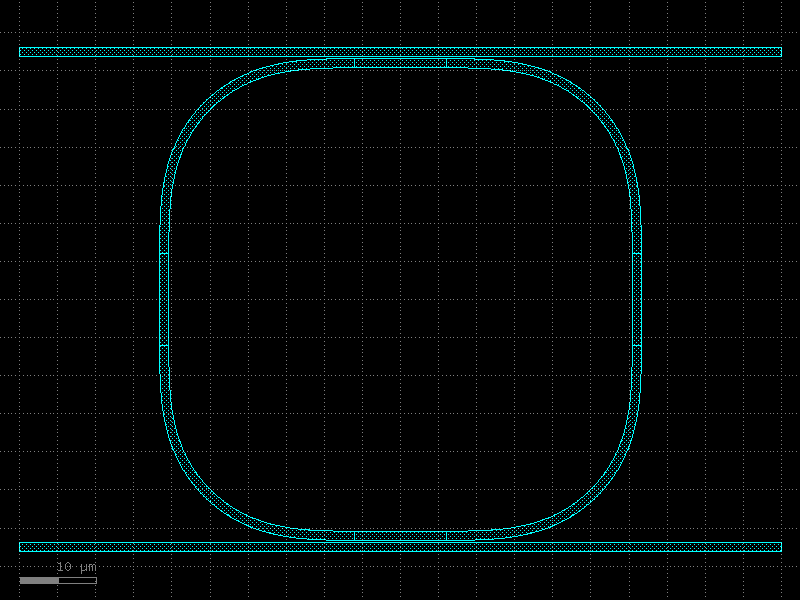

In [ ]:
gf.clear_cache()

RaceTrack_ADF = gf.Component("RaceTrack_ADF")

ring = RaceTrack_ADF << Racetrack(
    LengthX=CouplingLengthX*1e6, LengthY=CouplingLengthY*1e6,
    BendRadius=Radius*1e6, WgWidth=WgWidth*1e6, Euler=Euler, Layer=(2,0)
)

WgPosY    = (CouplingLengthY/2 + Radius+WgWidth/2+Gap+WidthIO/2) * 1e6
XOffset = -Length*1e6 / 2
YOffset =  -WidthIO*1e6/2

WgUp  = RaceTrack_ADF << Straight(Length=Length*1e6, WgWidth=WidthIO*1e6, Layer=(2,0))
WgBot = RaceTrack_ADF << Straight(Length=Length*1e6, WgWidth=WidthIO*1e6, Layer=(2,0))

WgBot.move((XOffset,  YOffset+WgPosY))
WgUp.move((XOffset,  YOffset-WgPosY))

RaceTrack_ADF.write_gds("Ring_ADF.gds")
RaceTrack_ADF.plot()

In [5]:
f.gdsimport("Ring_ADF.gds", "RaceTrack_ADF", "2:0", Material, 0, Height)

if use_index:
    f.set("material", "<Object defined dielectric>")
    f.set("index", Index)



In [ ]:

WgPosY        = CouplingLengthY/2 + Radius + Gap + WgWidth/2+WidthIO/2 # meters

SpanX = 2 * (Radius + CouplingLengthX) + 10*WgWidth
SpanY = 2 * (WgPosY + 3*WgWidth)


x_sim = 0
y_sim = 0

x0 = CouplingLengthX/2+ Radius
y0 = -0

Sim_span_x = 2 * (Radius + CouplingLengthX) + 10*WgWidth
Sim_span_y = 2 * (WgPosY + 3*WgWidth)

offsetX = 4e-6 +(LambdaStart+LambdaStop)/2
offsetY = 2e-6

SourcePosX =  x_sim-(Sim_span_x/2) +offsetX
SourcePosY =  Radius+WgWidth/2+Gap+WidthIO/2 + CouplingLengthY/2
TH_PosX    =  - SourcePosX + offsetX/2 
TH_PosY    =  WgPosY

DR_PosX    =  SourcePosX
DR_PosY    =  -WgPosY

Field_PosX = Sim_span_x- 2.5*offsetX
Filed_PosY = Sim_span_y- 2*offsetY



#------------------------------------------------------------
# varFDTD
#------------------------------------------------------------

f.addvarfdtd()
f.set("x0",CouplingLengthX/2+ Radius)
f.set("y0",0)
f.set("x", x_sim);          
f.set("x span", Sim_span_x)
f.set("y", y_sim);          
f.set("y span", Sim_span_y)
f.set("z", Height/2);   
f.set("z span", 8*Height)

f.set("simulation time", SimulationTime)
f.set("background material", BackgroundMaterial)
f.set("set simulation bandwidth", 1)
f.set("bandwidth", "broadband")
f.set("simulation wavelength min", LambdaStart)
f.set("simulation wavelength max", LambdaStop)
f.set("auto shutoff min", decay_time)

f.set("x min bc", "PML"); f.set("x max bc", "PML")
f.set("y min bc", "PML"); f.set("y max bc", "PML")
f.set("z min bc", "PML"); f.set("z max bc", "PML")

# # Test points on ring (45°, 135°, 225°, 315°)
# theta = [2, 90,180,270]
# test_points = np.array([
#     [(Radius+CouplingLengthX/2) * np.cos(np.radians(t)) for t in theta],
#     [(Radius+CouplingLengthY/2) * np.sin(np.radians(t)) for t in theta]
# ])
# f.set("test points", test_points)


In [ ]:

#------------------------------------------------------------
# Mode Source
#------------------------------------------------------------

f.addmodesource()
f.set("name", "ModeSource")
f.set("x", SourcePosX)  # Aligned with the right ring
f.set("y", SourcePosY)
f.set("y span", 2 * WgWidth)
f.set("use relative coordinates", 1)
f.set("injection axis", "x-axis")
f.set("direction", "Forward")
f.set("amplitude", 1.0)
f.set("phase", 0)
f.set("mode selection", "fundamental mode")
f.set("set wavelength", 1)
f.set("wavelength start", LambdaStart)
f.set("wavelength stop", LambdaStop)


In [ ]:

#------------------------------------------------------------
# Monitors
#------------------------------------------------------------

# THROUGH - output end of WgUp
f.adddftmonitor()
f.set("name", "Through")
f.set("monitor type", "Linear Y")
f.set("x",  TH_PosX)
f.set("y",  TH_PosY)
f.set("y span", 4*WgWidth)
f.set("z", Height/2)
f.set("override global monitor settings", 1)
f.set("use source limits", 1)
f.set("frequency points", FrequencyPoints)

f.set("output Ex", 0)
f.set("output Ey", 0)
f.set("output Ez", 0)
f.set("output Hx", 0)
f.set("output Hy", 0)
f.set("output Hz", 0)


# DROP - output end of WgBot
f.adddftmonitor()
f.set("name", "Drop")
f.set("monitor type", "Linear Y")
f.set("x",  DR_PosX)
f.set("y", DR_PosY)
f.set("y span", 4*WgWidth)
f.set("z", Height/2)
f.set("override global monitor settings", 1)
f.set("use source limits", 1)
f.set("frequency points", FrequencyPoints)

f.set("output Ex", 0)
f.set("output Ey", 0)
f.set("output Ez", 0)
f.set("output Hx", 0)
f.set("output Hy", 0)
f.set("output Hz", 0)


In [9]:

#------------------------------------------------------------
# MONITOR: Field
#------------------------------------------------------------
f.adddftmonitor()
f.set("name", "Field Monitor")
f.set("monitor type", "2D Z-normal")
f.set("x", x_sim)
f.set("x span",Field_PosX)
f.set("y", y_sim)
f.set("y span", Filed_PosY)
f.set("z", Height / 2)
f.set("override global monitor settings", 1)
f.set("use wavelength spacing", 1)
f.set("wavelength center", 1550E-9)
f.set("wavelength span", 1E-9)
f.set("frequency points", 1)

f.set("output Hx", 0)
f.set("output Hy", 0)
f.set("output Hz", 0)

In [ ]:
#------------------------------------------------------------
# Run
#------------------------------------------------------------
f.run()

In [ ]:
tag      = f"RaceTrack_R{Radius*1e6:.0f}um_W{WgWidth*1e9:.0f}nm_WIO{WidthIO*1e9:.0f}nm__Gap{Gap*1e9:.0f}nm_LcX{CouplingLengthX*1e6:.0f}um_LcY{CouplingLengthY*1e6:.0f}um"
fname     = data_save_dir / f"{tag}.txt"


#------------------------------------------------------------
# Extract Results
#------------------------------------------------------------
try:
    T_TH = f.getresult("TH", "T")
    T_DR = f.getresult("DR", "T")

    Tx_Through = np.abs(T_TH["T"].flatten())
    Tx_Drop    = np.abs(T_DR["T"].flatten())
    Wavelength = T_TH["lambda"].flatten()
except Exception as e:
    print(f"  ⚠ SKIPPED | {e}")

Tx_total_out = Tx_Through + Tx_Drop

idx_1550        = np.argmin(np.abs(Wavelength - 1550e-9))
loss_dB_1550    = -10 * np.log10(Tx_total_out[idx_1550])

print(f"Loss={loss_dB_1550:.2f} dB")

#------------------------------------------------------------
# E-field plot (save only, no show)
#------------------------------------------------------------
E_field    = f.getresult("Field Monitor", "E")
idx_1550_E = np.argmin(np.abs(E_field['lambda'].flatten() - 1550e-9))


fig_path = data_save_dir / f"Efield_3Ring{tag}.png"

try:
    x = E_field['x'].flatten() * 1e6
    y = E_field['y'].flatten() * 1e6
    E_int = np.abs(E_field['E'][:, :, 0, idx_1550_E, 1]).T**2
    E_dB  = 10 * np.log10(E_int / E_int.max() + 1e-20)
    plt.figure(figsize=(12, 12))
    plt.imshow(E_dB,
            aspect='auto', cmap='hot', origin='lower',
            extent=[x.min(), x.max(), y.min(), y.max()],
            vmin=-40, vmax=0)
    plt.xlabel('x (µm)')
    plt.ylabel('y (µm)')
    plt.colorbar(label='|Ey|² (dB)')
    plt.title(f'Field Profile at 1550nm | {tag}')
    plt.savefig(fig_path, dpi=600, bbox_inches='tight')
    plt.close('all')
except Exception as e:
    print(f"  E-field save failed: {e}")
    plt.close('all')

In [ ]:

#------------------------------------------------------------
# Plot
#------------------------------------------------------------
fig1 = plt.figure()
plt.plot(Wavelength*1e9, Tx_Through, label="Through")
plt.plot(Wavelength*1e9, Tx_Drop,    label="Drop")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmission")
plt.title(f"3 Ring Test - {tag}", fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig(data_save_dir / f"{fname}_lin.png", dpi=300, bbox_inches='tight')
mplcursors.cursor(hover=True)
disconnect_zoom = zoom_factory(plt.gca())
plt.show()

fig2 = plt.figure()
plt.plot(Wavelength*1e9, 10*np.log10(Tx_Through), label="Through")
plt.plot(Wavelength*1e9, 10*np.log10(Tx_Drop),    label="Drop")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmission (dB)")
plt.title(f"3 Ring Test-log - {tag}",fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig(data_save_dir / f"{fname}.png", dpi=300, bbox_inches='tight')
mplcursors.cursor(hover=True)
disconnect_zoom = zoom_factory(plt.gca())
plt.show()

#------------------------------------------------------------
# Save Data
#------------------------------------------------------------

meta = {
    "Width_nm"          : WgWidth  * 1e9,
    "Height_nm"         : Height * 1e9,
    "Radius_um"         : Radius * 1e6,
    "Gap_nm"            : Gap    * 1e9,
    "LcX"               : CouplingLengthX * 1e6,
    "LcY"               : CouplingLengthY * 1e6,
    "Material"          : Material,
    "Index"             : Index,
    "use_index"         : use_index,
    "Timestamp"         : time.strftime("%Y%m%d_%H%M%S"),
}

with open(fname, "w") as file:
    for k, v in meta.items():
        file.write(f"# {k}: {v}\n")
    file.write("# Wavelength_nm\tTx_Through\tTx_Drop\n")

data = np.column_stack([Wavelength*1e9, Tx_Through, Tx_Drop])
with open(fname, "ab") as file:
    np.savetxt(file, data, delimiter="\t")

print(f"Saved: {fname}")